# Case Study Task 1 — Оценка и анализ загрязнения воздуха: г. Павлодар

**Курс:** CSE-2506M · **Кейс:** *Assessment and Analysis of Air Pollution Levels in Major Cities of Kazakhstan*

Ноутбук закрывает методологию из задания (раздел 5) по шагам:

| Раздел ноутбука | Пункт задания |
|---|---|
| 1–3. Загрузка, контроль качества, покрытие данных | 5.1 Data Collection (очистка пропусков и некорректных показаний) |
| 4–6. Временные ряды, сезонность, декомпозиция, суточный цикл | 5.2 Data Analysis, 5.3 Visualization |
| 7. Связь с погодой | 5.2 Correlation with weather |
| 8. Сравнение с ВОЗ и нормами РК, дни превышения | 5.4 Evaluation |
| 9. Сравнение постов (районов) и «сигналы» источников | Heatmaps comparing locations, bar charts ranking sources |
| 10. Оценка риска для здоровья | Assess health risks |
| 11. ML: прогноз PM2.5 на завтра | 7. Advanced Extensions — forecasting |
| 12. ML: поиск аномальных дней (Isolation Forest) | 7. Advanced Extensions — anomaly detection |
| 13. Выводы и рекомендации | 5.5 Recommendations |

**Данные:**
* `data/*.csv` — часовые измерения 7 загрязнителей (PM2.5, PM10, NO₂, SO₂, CO, H₂S, O₃) на 5 автоматических постах Казгидромета в Павлодаре (PCP #3 … #7), 2021–2026.
* `data/weather_pavlodar_daily.csv` — суточная погода (температура, ветер, влажность, осадки) из архива **Open-Meteo** (ERA5-реанализ) для координат Павлодара. Скачан заранее, поэтому ноутбук работает без интернета.

> Ограничение: в наборе данных есть только Павлодар, поэтому «сравнение городов» из задания заменено сравнением постов (районов) внутри города, а другие города обсуждаются по литературе в отчёте.

## 0. Импорт библиотек и настройки

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# statsmodels — классическая сезонная декомпозиция временного ряда
from statsmodels.tsa.seasonal import seasonal_decompose

# scikit-learn — модели машинного обучения и метрики
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)  # прячем шумные предупреждения pandas
plt.style.use("ggplot")
pd.set_option("display.float_format", "{:.2f}".format)

DATA_DIR = "data"
TZ = "Asia/Almaty"     # местное время Павлодара: суточный цикл считаем по местным часам, а не по UTC
RANDOM_STATE = 42      # фиксируем случайность, чтобы результаты воспроизводились у всей команды

# Список загрязнителей = имена файлов в папке data/
POLLUTANTS = ["pm2_5", "pm10", "no2", "so2", "co", "h2s", "o3"]
LABELS = {"pm2_5": "PM2.5", "pm10": "PM10", "no2": "NO₂", "so2": "SO₂",
          "co": "CO", "h2s": "H₂S", "o3": "O₃"}

### Нормативы качества воздуха (µg/m³, средние за 24 часа)

* **ВОЗ 2021** (WHO Global Air Quality Guidelines) — рекомендуемые уровни, основанные на данных о здоровье.
* **ПДК РК, среднесуточная** (гигиенические нормативы РК, ПДКсс) — национальная норма. Для H₂S в РК установлена только максимально-разовая ПДК (8 µg/m³), её и используем.
* Для O₃ у ВОЗ норматив 8-часовой (100 µg/m³); для простоты сравниваем с суточным средним — это мягкая (заниженная) оценка превышений.

In [2]:
# Суточные нормативы в µg/m³. None = норматива нет.
WHO_24H = {"pm2_5": 15, "pm10": 45, "no2": 25, "so2": 40, "co": 4000, "h2s": None, "o3": 100}
KZ_MPC_24H = {"pm2_5": 35, "pm10": 60, "no2": 40, "so2": 50, "co": 3000, "h2s": 8, "o3": 30}

# Годовые нормативы ВОЗ 2021 — для оценки долгосрочного риска
WHO_ANNUAL = {"pm2_5": 5, "pm10": 15, "no2": 10}

pd.DataFrame({"ВОЗ 2021 (24ч)": WHO_24H, "ПДК РК (сс)": KZ_MPC_24H}).rename(index=LABELS)

,ВОЗ 2021 (24ч),ПДК РК (сс)
PM2.5,15.00,35
PM10,45.00,60
NO₂,25.00,40
SO₂,40.00,50
CO,4000.00,3000
H₂S,NaN,8
O₃,100.00,30


## 1. Загрузка данных

Исходные метки времени записаны со смещением `-08:00`/`-07:00` (часовой пояс сервера-источника), причём смещение меняется из-за перехода на летнее время. Поэтому:
1. парсим с `utc=True` — все строки приводятся к единому UTC (иначе pandas выдаёт ошибку «mixed time zones», из-за которой старая версия ноутбука падала);
2. переводим в местное время Павлодара.

In [3]:
def load_pollutant(name: str) -> pd.DataFrame:
    # Читает один CSV-файл загрязнителя и возвращает таблицу в «длинном» формате.
    path = os.path.join(DATA_DIR, f"{name}.csv")
    df = pd.read_csv(path)
    df = df[df["city"].str.contains("Pavlodar", case=False, na=False)]   # страховка: только Павлодар
    df["time"] = pd.to_datetime(df["datetime_utc"], utc=True).dt.tz_convert(TZ)
    df["pollutant"] = name
    return df[["time", "station_name", "lat", "lon", "pollutant", "value_ugm3"]]


raw = pd.concat([load_pollutant(p) for p in POLLUTANTS], ignore_index=True)
raw = raw.rename(columns={"station_name": "station", "value_ugm3": "value"})

print(f"Всего часовых записей: {len(raw):,}")
print(f"Период: {raw['time'].min():%Y-%m-%d} → {raw['time'].max():%Y-%m-%d}")
raw.groupby(["pollutant", "station"]).size().unstack().rename(index=LABELS)

Всего часовых записей: 723,752
Период: 2021-03-24 → 2026-05-01


station,PCP #3,PCP #4,PCP #5,PCP #6,PCP #7
pollutant,,,,,
CO,33888.00,33924.00,34253.00,19205.00,34109.00
H₂S,33835.00,33850.00,34257.00,34037.00,34208.00
NO₂,8914.00,22869.00,24247.00,20265.00,25922.00
O₃,1478.00,1478.00,1477.00,NaN,1299.00
PM10,NaN,NaN,19475.00,9356.00,23851.00
PM2.5,NaN,NaN,25340.00,15232.00,27814.00
SO₂,33836.00,33851.00,34257.00,34037.00,33188.00


Координаты постов — пригодятся при обсуждении, какой пост ближе к промзоне / центру.

In [4]:
stations = raw.groupby("station")[["lat", "lon"]].first()
stations

,lat,lon
station,,
PCP #3,52.26,76.96
PCP #4,52.25,76.98
PCP #5,52.28,76.95
PCP #6,52.27,76.94
PCP #7,52.29,76.94


## 2. Контроль качества данных (Data Cleaning)

Автоматические датчики часто выдают технически некорректные значения. Применяем три прозрачных правила:

1. **Дубликаты и отрицательные значения** — удаляем.
2. **Изолированные выбросы (spikes):** значение выше 99.9-го перцентиля для пары «пост × загрязнитель» **и** более чем в 5 раз выше скользящей 24-часовой медианы. Настоящий смог длится часами (медиана тоже растёт), а одиночный «прыжок» — это сбой датчика.
3. **«Залипший» датчик (flatline):** если за сутки стандартное отклонение показаний < 5 % от типичного уровня загрязнителя, датчик, скорее всего, стоит на нижнем пределе обнаружения. Такие сутки исключаются.

После этого считаем **суточное среднее** только для суток, где есть ≥ 18 из 24 часов (правило 75 % полноты, стандарт ВОЗ/EPA для суточных средних).

In [5]:
df = raw.drop_duplicates(["time", "station", "pollutant"]).copy()
n0 = len(df)
df = df[df["value"] >= 0]
df = df.sort_values(["pollutant", "station", "time"])

# --- Правило 2: изолированные выбросы -------------------------------------------------
grp = df.groupby(["pollutant", "station"])["value"]
p999 = grp.transform(lambda s: s.quantile(0.999))
rolling_med = grp.transform(lambda s: s.rolling(24, min_periods=6, center=True).median())
is_spike = (df["value"] > p999) & (df["value"] > 5 * rolling_med)
print(f"Удалено изолированных выбросов: {is_spike.sum():,}")
df = df[~is_spike]

# --- Правило 3: залипший датчик ---------------------------------------------------------
df["date"] = df["time"].dt.tz_localize(None).dt.normalize()   # локальная дата без часового пояса
typical_level = df.groupby("pollutant")["value"].median()      # «типичный уровень» каждого газа
day_std = df.groupby(["pollutant", "station", "date"])["value"].transform("std")
is_flat = day_std < 0.05 * df["pollutant"].map(typical_level)
print(f"Удалено часов с 'залипшим' датчиком: {is_flat.sum():,}")
df = df[~is_flat]

print(f"Осталось {len(df):,} из {n0:,} записей ({len(df) / n0:.1%})")

Удалено изолированных выбросов: 415
Удалено часов с 'залипшим' датчиком: 148,776
Осталось 574,561 из 723,752 записей (79.4%)


Какая доля данных каждого поста прошла контроль качества — это важно честно показать на защите:

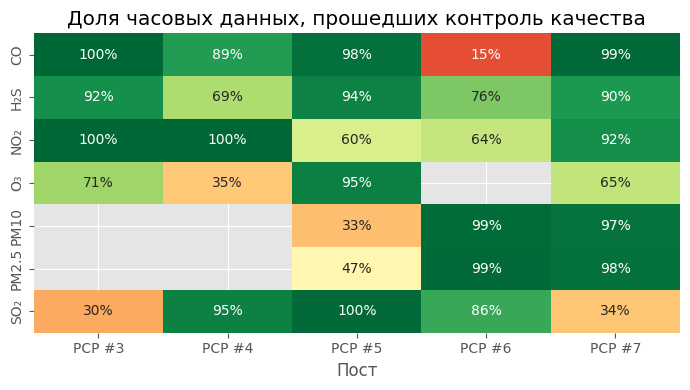

In [6]:
kept = df.groupby(["pollutant", "station"]).size()
total = raw.groupby(["pollutant", "station"]).size()
qc_share = (kept / total).unstack().rename(index=LABELS)

plt.figure(figsize=(7, 4))
sns.heatmap(qc_share, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1, cbar=False)
plt.title("Доля часовых данных, прошедших контроль качества")
plt.xlabel("Пост"); plt.ylabel("")
plt.tight_layout(); plt.show()

### Суточные средние по постам и по городу

In [7]:
# Суточная агрегация по каждому посту с правилом полноты 18/24 часа
daily_station = (df.groupby(["pollutant", "station", "date"])["value"]
                   .agg(["mean", "count"]))
daily_station = daily_station[daily_station["count"] >= 18]["mean"]

# «Городское» значение = среднее по всем постам, у которых в этот день есть валидные данные.
# Пивот: строки — даты, столбцы — загрязнители.
city = (daily_station.groupby(["date", "pollutant"]).mean()
                      .unstack("pollutant")
                      .reindex(columns=POLLUTANTS))
city = city.asfreq("D")   # явный дневной индекс: пропущенные дни становятся NaN (видно разрывы)
print(f"Дней в периоде: {len(city)}, дней с валидным PM2.5: {city['pm2_5'].notna().sum()}")
city.describe().T.rename(index=LABELS)

Дней в периоде: 1862, дней с валидным PM2.5: 1212


,count,mean,std,min,25%,50%,75%,max
pollutant,,,,,,,,
PM2.5,1212.00,11.77,9.10,1.98,6.19,8.86,14.33,86.49
PM10,962.00,23.04,14.83,4.15,12.79,19.24,29.22,112.40
NO₂,1414.00,33.90,41.12,0.21,4.12,26.78,45.75,633.94
SO₂,1423.00,11.83,14.26,1.36,5.46,7.81,12.28,141.31
CO,1423.00,452.54,282.42,118.94,274.83,367.82,541.30,2806.50
H₂S,1420.00,1.04,0.68,0.01,0.60,0.96,1.29,13.25
O₃,60.00,31.83,17.48,5.08,22.13,30.59,41.60,77.06


## 3. Покрытие данных

Прежде чем делать выводы о трендах, нужно увидеть, где данные вообще есть. Белые полосы = нет измерений (например, по PM2.5 почти нет данных с середины 2023 до начала 2025).

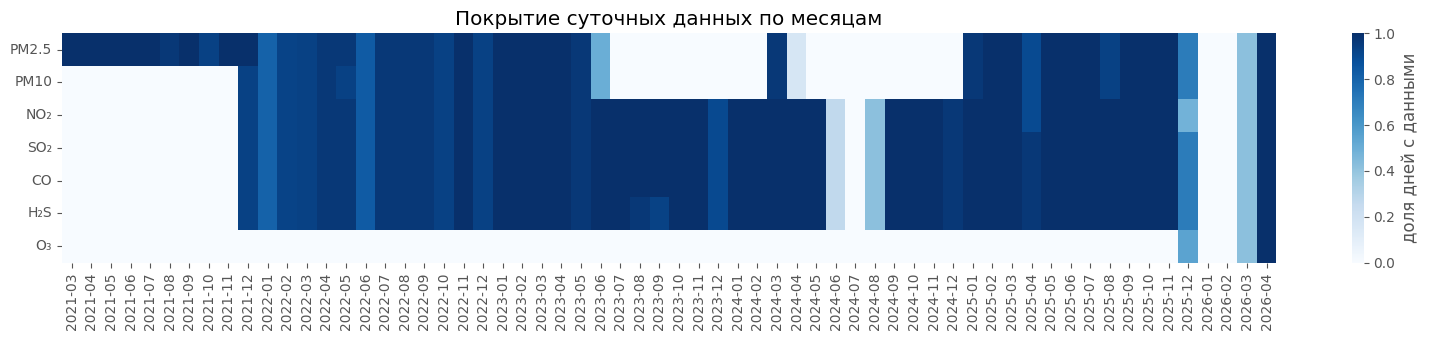

In [8]:
coverage = city.notna().resample("MS").mean().T.rename(index=LABELS)
coverage.columns = coverage.columns.strftime("%Y-%m")

plt.figure(figsize=(16, 3.5))
sns.heatmap(coverage, cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "доля дней с данными"})
plt.title("Покрытие суточных данных по месяцам")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

## 4. Временные ряды: загрязнители по месяцам

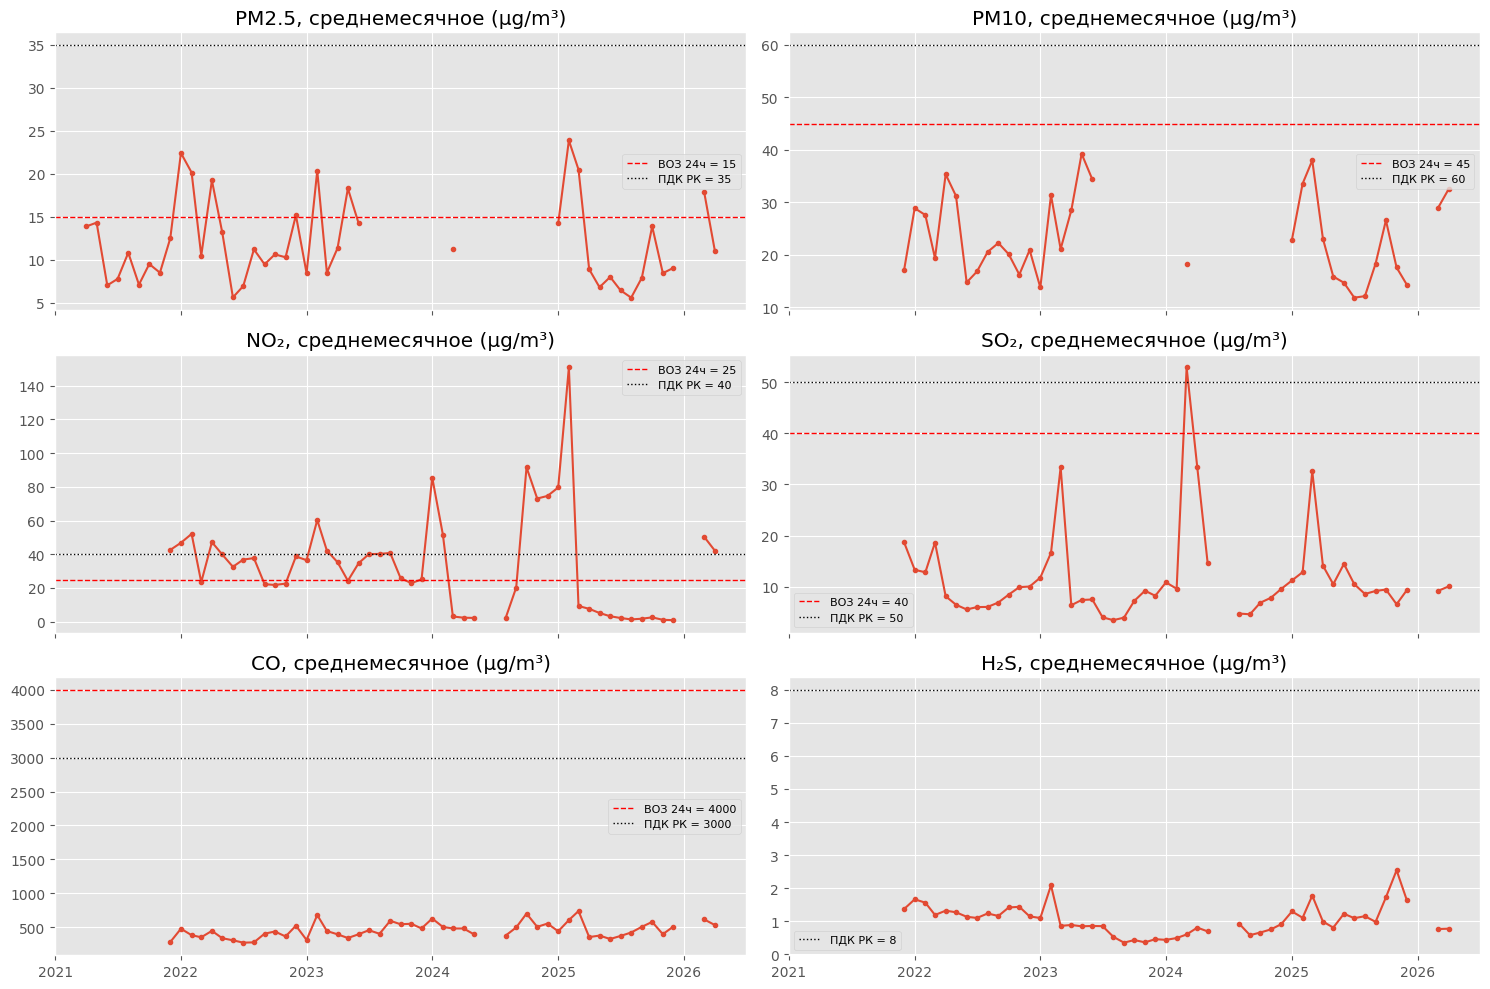

In [9]:
# Месячные средние; месяц учитываем, только если в нём ≥ 10 дней данных, иначе среднее ненадёжно
monthly = city.resample("MS").mean()
monthly = monthly.where(city.resample("MS").count() >= 10)

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
for ax, p in zip(axes.flat, ["pm2_5", "pm10", "no2", "so2", "co", "h2s"]):
    ax.plot(monthly.index, monthly[p], marker="o", ms=3)
    if WHO_24H[p]:
        ax.axhline(WHO_24H[p], color="red", ls="--", lw=1, label=f"ВОЗ 24ч = {WHO_24H[p]}")
    ax.axhline(KZ_MPC_24H[p], color="black", ls=":", lw=1, label=f"ПДК РК = {KZ_MPC_24H[p]}")
    ax.set_title(f"{LABELS[p]}, среднемесячное (µg/m³)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### PM2.5: суточные значения и норматив ВОЗ

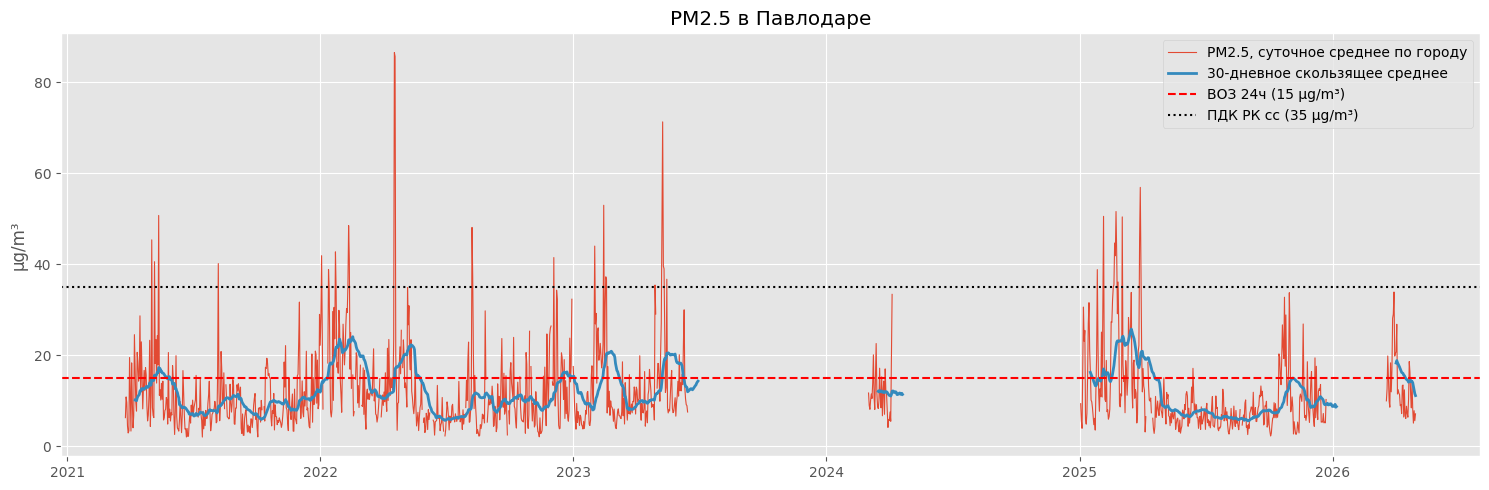

In [10]:
plt.figure(figsize=(15, 5))
plt.plot(city.index, city["pm2_5"], lw=0.8, label="PM2.5, суточное среднее по городу")
plt.plot(city.index, city["pm2_5"].rolling(30, min_periods=15).mean(), lw=2, label="30-дневное скользящее среднее")
plt.axhline(WHO_24H["pm2_5"], color="red", ls="--", label="ВОЗ 24ч (15 µg/m³)")
plt.axhline(KZ_MPC_24H["pm2_5"], color="black", ls=":", label="ПДК РК сс (35 µg/m³)")
plt.title("PM2.5 в Павлодаре")
plt.ylabel("µg/m³"); plt.legend(); plt.tight_layout(); plt.show()

## 5. Сезонность

### 5.1 Среднемесячный профиль (климатология) и отопительный сезон

Отопительный сезон определяем **по данным о погоде**, а не по календарю: день считается «отопительным», если среднесуточная температура < +8 °C (стандартный критерий начала отопления в СНГ).

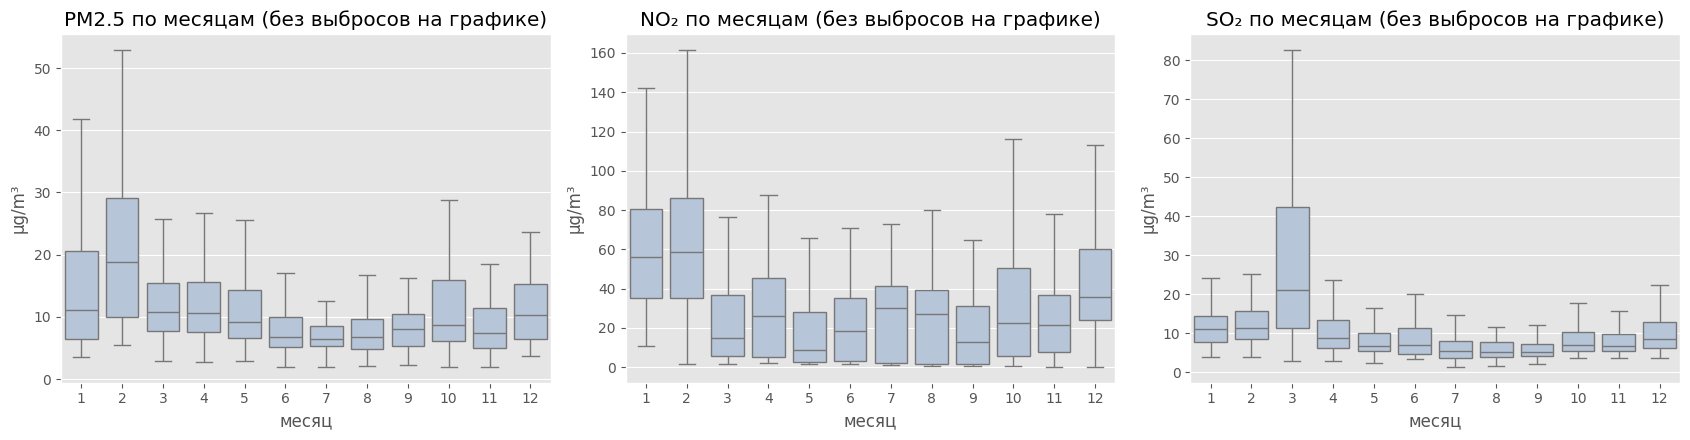

In [11]:
# Погода: суточные данные Open-Meteo, заранее сохранённые в data/
weather = pd.read_csv(os.path.join(DATA_DIR, "weather_pavlodar_daily.csv"), parse_dates=["date"]).set_index("date")
city = city.join(weather)                           # добавляем столбцы temp_c, wind_kmh, humidity_pct, precip_mm
city["heating"] = city["temp_c"] < 8                 # флаг отопительного дня
city["month"] = city.index.month

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, p in zip(axes, ["pm2_5", "no2", "so2"]):
    sns.boxplot(data=city, x="month", y=p, ax=ax, color="lightsteelblue", showfliers=False)
    ax.set_title(f"{LABELS[p]} по месяцам (без выбросов на графике)")
    ax.set_xlabel("месяц"); ax.set_ylabel("µg/m³")
plt.tight_layout(); plt.show()

In [12]:
# Сравнение «отопительный vs неотопительный» период: среднее и во сколько раз выше зимой
season_tbl = city.groupby("heating")[POLLUTANTS].mean().T
season_tbl.columns = ["Неотопительный", "Отопительный"]
season_tbl["Рост зимой, раз"] = season_tbl["Отопительный"] / season_tbl["Неотопительный"]
season_tbl.rename(index=LABELS)

,Неотопительный,Отопительный,"Рост зимой, раз"
PM2.5,10.03,13.26,1.32
PM10,22.57,23.38,1.04
NO₂,24.10,41.67,1.73
SO₂,7.92,14.90,1.88
CO,408.83,486.97,1.19
H₂S,0.92,1.13,1.22
O₃,35.37,30.31,0.86


### 5.2 Сезонная декомпозиция (тренд + сезонность + остаток)

Берём самый длинный непрерывный отрезок среднемесячного PM2.5 (апрель 2021 — май 2023, 26 месяцев ≥ 2 годовых цикла) и раскладываем аддитивной моделью с периодом 12 месяцев.

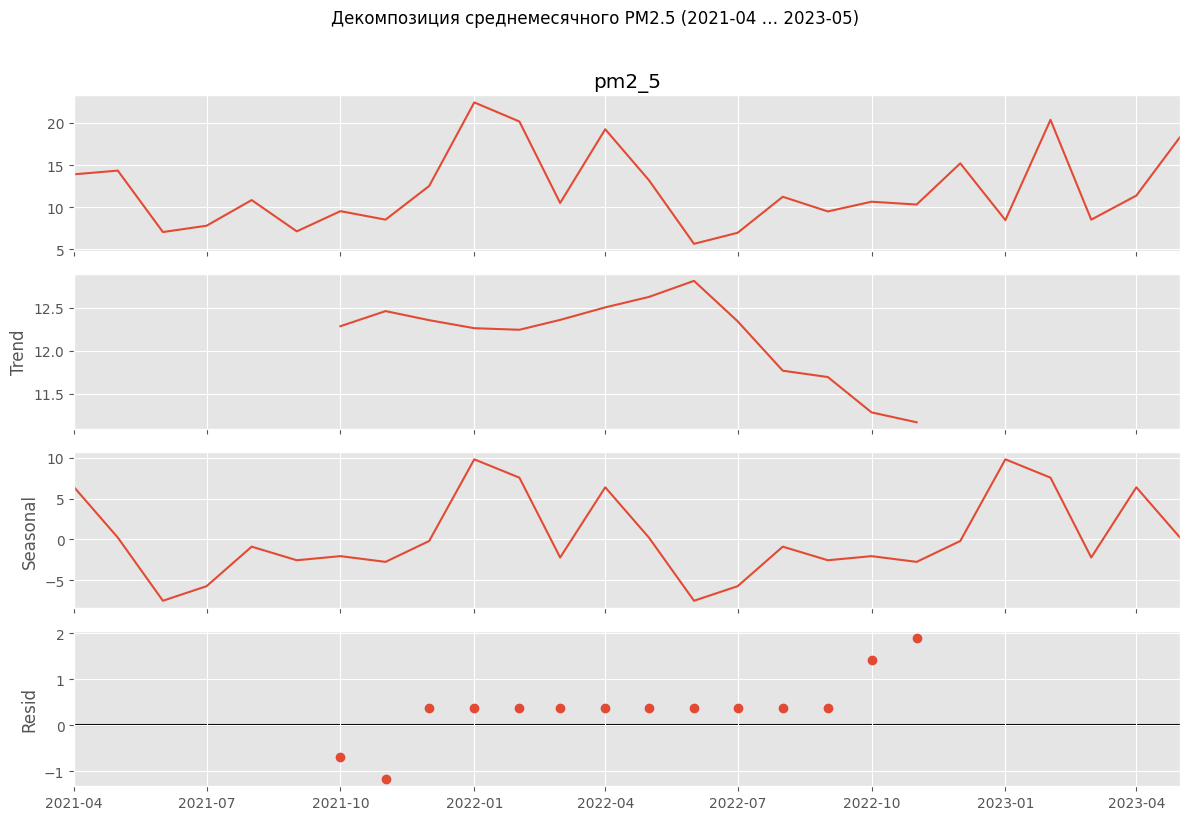

Размах сезонной компоненты: 17.3 µg/m³ (пик в месяце 01, минимум в месяце 06)


In [13]:
pm_month = monthly["pm2_5"]["2021-04":"2023-05"].interpolate()   # единичные пропуски интерполируем
decomp = seasonal_decompose(pm_month, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Декомпозиция среднемесячного PM2.5 (2021-04 … 2023-05)", y=1.02)
plt.tight_layout(); plt.show()

seasonal_amp = decomp.seasonal.max() - decomp.seasonal.min()
print(f"Размах сезонной компоненты: {seasonal_amp:.1f} µg/m³ "
      f"(пик в месяце {decomp.seasonal.idxmax():%m}, минимум в месяце {decomp.seasonal.idxmin():%m})")

## 6. Суточный цикл (по местному времени)

Форма суточного профиля подсказывает источник: **два пика (утро и вечер)** характерны для транспорта, **вечерне-ночной рост** зимой — для печного/котельного отопления и приземных инверсий.

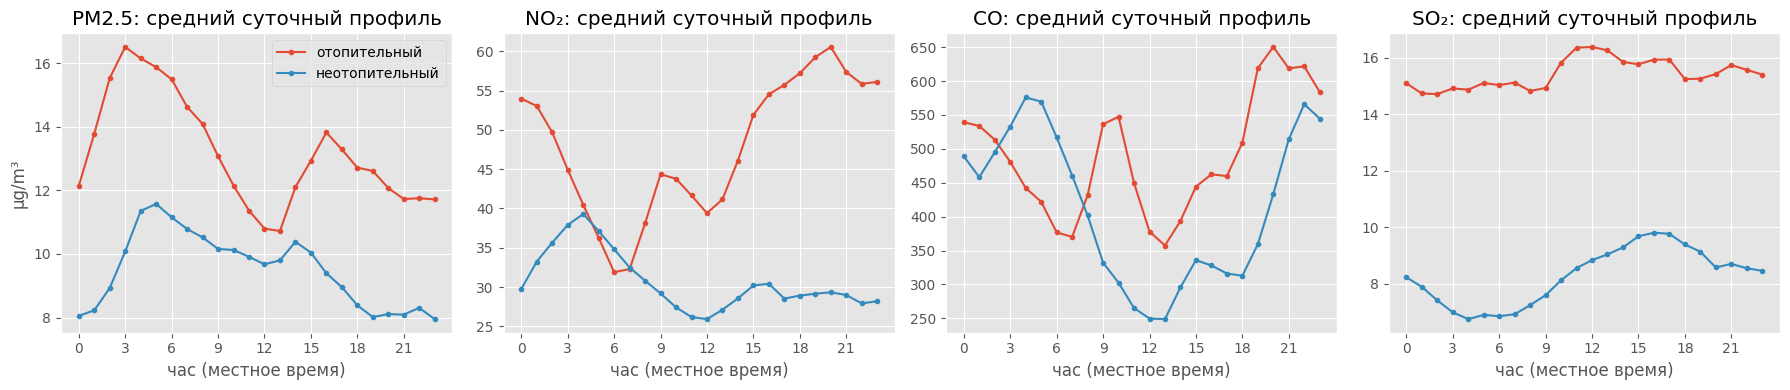

In [14]:
hourly = df.copy()
hourly["hour"] = hourly["time"].dt.hour
hourly["heating"] = hourly["date"].map(city["heating"])   # отопительный ли это день
diurnal = hourly.groupby(["pollutant", "heating", "hour"])["value"].mean()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, p in zip(axes, ["pm2_5", "no2", "co", "so2"]):
    for flag, name in [(True, "отопительный"), (False, "неотопительный")]:
        ax.plot(diurnal[p][flag].index, diurnal[p][flag].values, marker=".", label=name)
    ax.set_title(f"{LABELS[p]}: средний суточный профиль")
    ax.set_xlabel("час (местное время)"); ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("µg/m³"); axes[0].legend()
plt.tight_layout(); plt.show()

## 7. Связь с погодой

Используем **корреляцию Спирмена** (ранговую): она устойчива к выбросам и не требует линейной зависимости.

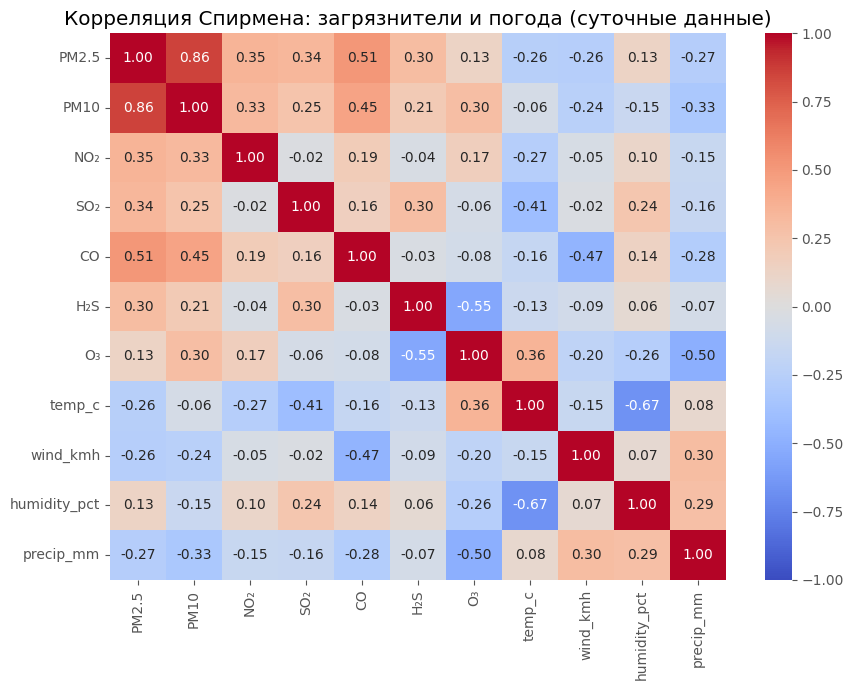

In [15]:
cols = POLLUTANTS + ["temp_c", "wind_kmh", "humidity_pct", "precip_mm"]
corr = city[cols].corr(method="spearman").rename(index=LABELS, columns=LABELS)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Корреляция Спирмена: загрязнители и погода (суточные данные)")
plt.tight_layout(); plt.show()

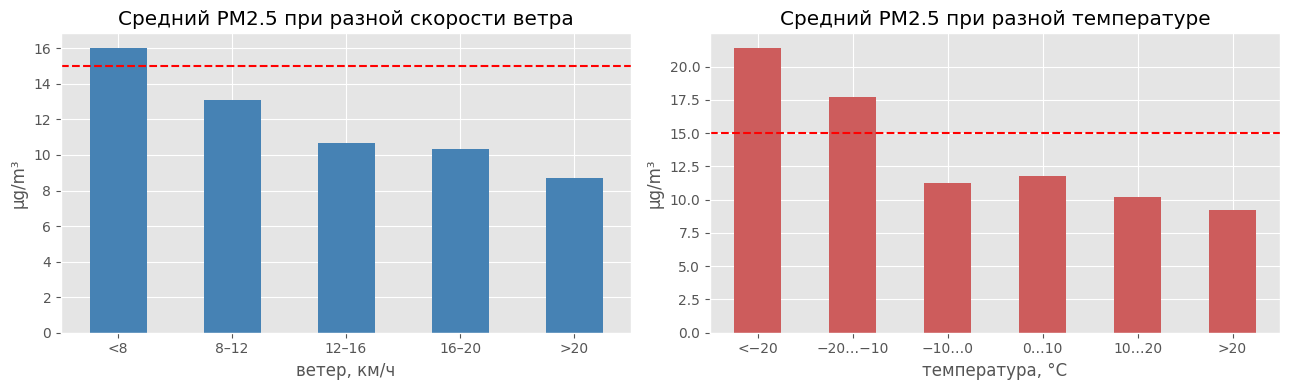

In [16]:
# Как PM2.5 зависит от ветра и температуры: средний PM2.5 по «корзинам» погодных условий
city["wind_bin"] = pd.cut(city["wind_kmh"], [0, 8, 12, 16, 20, 50], labels=["<8", "8–12", "12–16", "16–20", ">20"])
city["temp_bin"] = pd.cut(city["temp_c"], [-40, -20, -10, 0, 10, 20, 40],
                          labels=["<−20", "−20…−10", "−10…0", "0…10", "10…20", ">20"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
city.groupby("wind_bin", observed=True)["pm2_5"].mean().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Средний PM2.5 при разной скорости ветра"); axes[0].set_xlabel("ветер, км/ч")
city.groupby("temp_bin", observed=True)["pm2_5"].mean().plot.bar(ax=axes[1], color="indianred")
axes[1].set_title("Средний PM2.5 при разной температуре"); axes[1].set_xlabel("температура, °C")
for ax in axes:
    ax.axhline(WHO_24H["pm2_5"], color="red", ls="--"); ax.set_ylabel("µg/m³"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 8. Сравнение с нормативами: дни превышения

Считаем, в какой доле **дней с данными** суточное среднее по городу превышает норматив ВОЗ и ПДК РК. Долю используем вместо абсолютного числа дней, потому что в разные годы покрытие данных разное.

In [17]:
def exceedance_table(frame: pd.DataFrame) -> pd.DataFrame:
    # Для каждого загрязнителя: число дней с данными, дни > ВОЗ, дни > ПДК РК и их доли.
    rows = {}
    for p in POLLUTANTS:
        s = frame[p].dropna()
        row = {"дней с данными": len(s), "среднее": s.mean()}
        if WHO_24H[p]:
            row["дней > ВОЗ"] = int((s > WHO_24H[p]).sum())
            row["% > ВОЗ"] = 100 * (s > WHO_24H[p]).mean()
        row["дней > ПДК РК"] = int((s > KZ_MPC_24H[p]).sum())
        row["% > ПДК РК"] = 100 * (s > KZ_MPC_24H[p]).mean()
        rows[LABELS[p]] = row
    return pd.DataFrame(rows).T


exceed = exceedance_table(city)
exceed

,дней с данными,среднее,дней > ВОЗ,% > ВОЗ,дней > ПДК РК,% > ПДК РК
PM2.5,1212.00,11.77,282.00,23.27,37.00,3.05
PM10,962.00,23.04,76.00,7.90,24.00,2.49
NO₂,1414.00,33.90,741.00,52.40,428.00,30.27
SO₂,1423.00,11.83,55.00,3.87,38.00,2.67
CO,1423.00,452.54,0.00,0.00,0.00,0.00
H₂S,1420.00,1.04,NaN,NaN,1.00,0.07
O₃,60.00,31.83,0.00,0.00,31.00,51.67


In [18]:
# Дни превышения ВОЗ по PM2.5 по годам (с учётом полноты данных)
yearly = city["pm2_5"].groupby(city.index.year).agg(
    days_with_data="count",
    days_over_WHO=lambda s: (s > WHO_24H["pm2_5"]).sum(),
    mean="mean",
)
yearly["% дней > ВОЗ"] = 100 * yearly["days_over_WHO"] / yearly["days_with_data"]
yearly

,days_with_data,days_over_WHO,mean,% дней > ВОЗ
date,,,,
2021,278,50,10.11,17.99
2022,341,98,12.80,28.74
2023,165,44,13.34,26.67
2024,35,8,11.78,22.86
2025,350,70,11.18,20.00
2026,43,12,13.15,27.91


### Периоды высокого риска

Самые загрязнённые дни (топ-10 по PM2.5) вместе с погодой: видно, что это морозные безветренные дни — типичная зимняя приземная инверсия.

In [19]:
city.nlargest(10, "pm2_5")[["pm2_5", "pm10", "no2", "so2", "temp_c", "wind_kmh", "humidity_pct"]]

,pm2_5,pm10,no2,so2,temp_c,wind_kmh,humidity_pct
date,,,,,,,
2022-04-18,86.49,112.40,33.80,14.61,11.30,18.10,59
2022-04-19,85.63,103.08,34.39,20.22,7.20,14.10,43
2023-05-10,71.25,91.69,19.82,8.96,13.40,10.40,37
2025-03-29,56.85,111.21,21.84,16.65,4.40,2.90,65
2023-02-14,52.92,62.43,72.62,16.33,-20.40,11.40,81
2025-02-22,51.55,69.66,2.03,13.35,-12.60,6.90,85
2021-05-13,50.68,NaN,NaN,NaN,14.60,21.20,45
2025-02-04,50.49,57.97,108.91,7.24,-7.00,4.30,93
2025-03-03,50.37,68.36,2.47,20.02,-12.60,6.60,90


## 9. Сравнение постов (районов города) и «сигналы» источников

### 9.1 Тепловая карта «пост × загрязнитель»

Значения нормированы на норматив ВОЗ (или ПДК РК для H₂S/O₃): **1.0 = ровно на уровне норматива**. Так газы с разными единицами становятся сопоставимы.

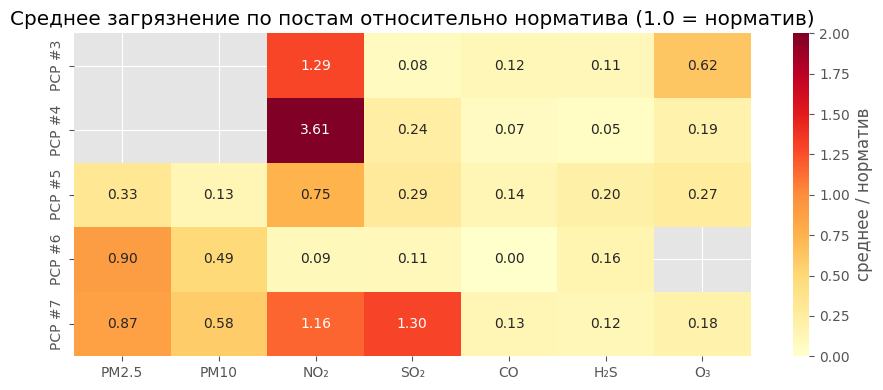

In [20]:
limit = {p: (WHO_24H[p] or KZ_MPC_24H[p]) for p in POLLUTANTS}
station_mean = daily_station.groupby(["station", "pollutant"]).mean().unstack("pollutant").reindex(columns=POLLUTANTS)
station_ratio = station_mean / pd.Series(limit)

plt.figure(figsize=(9, 4))
sns.heatmap(station_ratio.rename(columns=LABELS), annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=2,
            cbar_kws={"label": "среднее / норматив"})
plt.title("Среднее загрязнение по постам относительно норматива (1.0 = норматив)")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout(); plt.show()

### 9.2 Какой загрязнитель самый проблемный

Ранжируем загрязнители по доле дней выше норматива (ВОЗ, либо ПДК РК, если у ВОЗ нет суточного норматива).

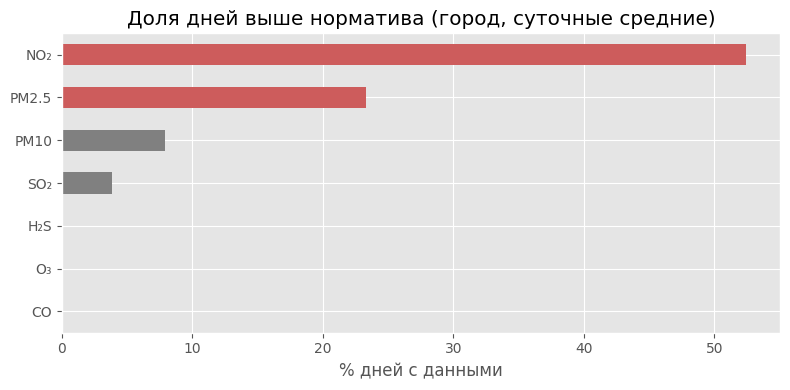

In [21]:
share_over = pd.Series({LABELS[p]: 100 * (city[p].dropna() > limit[p]).mean() for p in POLLUTANTS}).sort_values()

plt.figure(figsize=(8, 4))
share_over.plot.barh(color=["indianred" if v > 10 else "grey" for v in share_over])
plt.title("Доля дней выше норматива (город, суточные средние)")
plt.xlabel("% дней с данными")
plt.tight_layout(); plt.show()

### 9.3 «Сигналы» источников

Инвентаризации выбросов по предприятиям в открытом наборе нет, поэтому источники оцениваем по **косвенным признакам** из самих данных:

* **Отопление / сжигание угля** → во сколько раз загрязнитель выше в отопительный сезон;
* **Транспорт** → во сколько раз загрязнитель выше в часы пик (8–9 и 18–20 ч) чем ночью (2–5 ч) в неотопительный сезон (когда отопление не маскирует эффект);
* **Промышленность** → отношение максимума по постам к медиане по постам (локальный точечный источник даёт сильный перекос между районами).

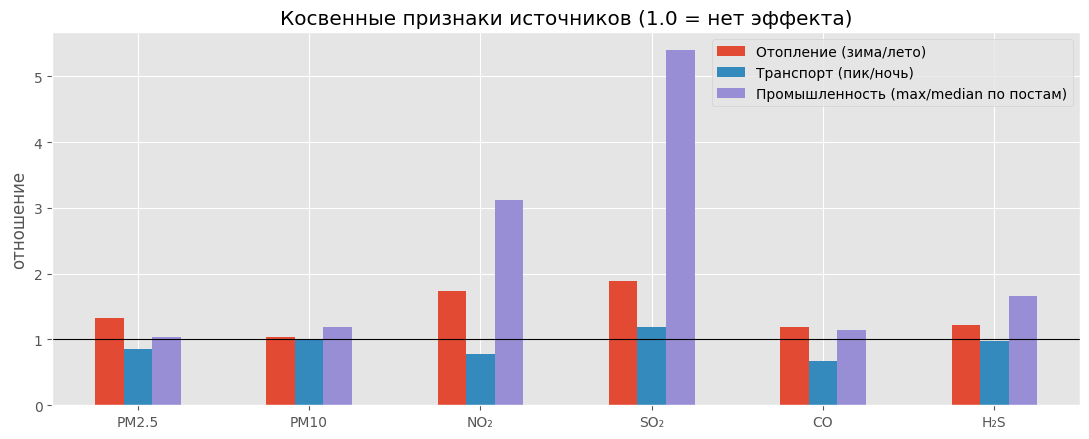

,Отопление (зима/лето),Транспорт (пик/ночь),Промышленность (max/median по постам)
PM2.5,1.32,0.86,1.04
PM10,1.04,1.00,1.19
NO₂,1.73,0.79,3.12
SO₂,1.88,1.20,5.40
CO,1.19,0.68,1.14
H₂S,1.22,0.98,1.67


In [22]:
warm = hourly[hourly["heating"] == False]
rush = warm[warm["hour"].isin([8, 9, 18, 19, 20])].groupby("pollutant")["value"].mean()
night = warm[warm["hour"].isin([2, 3, 4, 5])].groupby("pollutant")["value"].mean()

signals = pd.DataFrame({
    "Отопление (зима/лето)": season_tbl["Рост зимой, раз"],
    "Транспорт (пик/ночь)": rush / night,
    "Промышленность (max/median по постам)": station_mean.max() / station_mean.median(),
}).loc[["pm2_5", "pm10", "no2", "so2", "co", "h2s"]].rename(index=LABELS)

signals.plot.bar(figsize=(11, 4.5), rot=0)
plt.axhline(1, color="black", lw=0.8)
plt.title("Косвенные признаки источников (1.0 = нет эффекта)")
plt.ylabel("отношение")
plt.tight_layout(); plt.show()
signals

## 10. Оценка риска для здоровья

Для долгосрочного воздействия PM2.5 используем коэффициент из мета-анализа, на котором основаны нормативы ВОЗ 2021 (Chen & Hoek, 2020): **+8 % общей смертности на каждые +10 µg/m³** среднегодового PM2.5 (RR = 1.08). Считаем избыточный относительный риск относительно годового норматива ВОЗ 5 µg/m³.

> Это грубая оценка: берём среднее по всем доступным дням, а покрытие данных неполное.

In [23]:
RR_PER_10 = 1.08
annual_pm25 = city["pm2_5"].mean()
excess_risk = RR_PER_10 ** ((annual_pm25 - WHO_ANNUAL["pm2_5"]) / 10) - 1

print(f"Среднее PM2.5 за период: {annual_pm25:.1f} µg/m³ "
      f"= {annual_pm25 / WHO_ANNUAL['pm2_5']:.1f}× годового норматива ВОЗ ({WHO_ANNUAL['pm2_5']} µg/m³)")
print(f"Оценка избыточного риска общей смертности от PM2.5: +{excess_risk:.1%}")
for p in ["pm10", "no2"]:
    print(f"Среднее {LABELS[p]}: {city[p].mean():.1f} µg/m³ = {city[p].mean() / WHO_ANNUAL[p]:.1f}× годового норматива ВОЗ")

Среднее PM2.5 за период: 11.8 µg/m³ = 2.4× годового норматива ВОЗ (5 µg/m³)
Оценка избыточного риска общей смертности от PM2.5: +5.4%
Среднее PM10: 23.0 µg/m³ = 1.5× годового норматива ВОЗ
Среднее NO₂: 33.9 µg/m³ = 3.4× годового норматива ВОЗ


## 11. Машинное обучение: прогноз PM2.5 на завтра

**Постановка:** по данным, известным к концу дня *t*, предсказать среднесуточный PM2.5 на день *t+1*.

**Признаки:**
* лаги PM2.5 (вчера, позавчера, 3 дня и неделю назад) и скользящее среднее за 3 дня;
* вчерашние значения других загрязнителей (PM10, NO₂, SO₂, CO);
* погода на день прогноза (температура, ветер, влажность, осадки) — на практике берётся из метеопрогноза, здесь используем фактическую погоду как «идеальный прогноз» (это оговариваем в ограничениях);
* календарь: месяц в виде sin/cos (чтобы декабрь и январь были «рядом»), день недели, флаг отопительного сезона.

**Разбиение:** строго по времени — первые 80 % дней для обучения, последние 20 % для теста (перемешивание данных временного ряда дало бы «подглядывание в будущее»).

**Модели:** базовая «персистентность» (завтра = сегодня), линейная регрессия, случайный лес.

In [24]:
feat = pd.DataFrame(index=city.index)
feat["target"] = city["pm2_5"]                                    # что предсказываем (PM2.5 в день t+1)
for lag in [1, 2, 3, 7]:
    feat[f"pm25_lag{lag}"] = city["pm2_5"].shift(lag)             # shift работает на полном дневном индексе,
feat["pm25_roll3"] = city["pm2_5"].shift(1).rolling(3).mean()     # поэтому через разрывы лаги становятся NaN
for p in ["pm10", "no2", "so2", "co"]:
    feat[f"{p}_lag1"] = city[p].shift(1)
for w in ["temp_c", "wind_kmh", "humidity_pct", "precip_mm"]:
    feat[w] = city[w]
feat["month_sin"] = np.sin(2 * np.pi * city.index.month / 12)
feat["month_cos"] = np.cos(2 * np.pi * city.index.month / 12)
feat["dayofweek"] = city.index.dayofweek
feat["heating"] = city["heating"].astype(int)

# Обязательные признаки — таргет и лаги PM2.5; остальные пропуски заполним медианой обучающей выборки
feat = feat.dropna(subset=["target", "pm25_lag1", "pm25_lag2", "pm25_lag3", "pm25_lag7", "pm25_roll3"])
split = int(len(feat) * 0.8)
train, test = feat.iloc[:split], feat.iloc[split:]
X_cols = [c for c in feat.columns if c != "target"]
fill = train[X_cols].median()                                     # медиана ТОЛЬКО по train — без утечки из теста
X_train, X_test = train[X_cols].fillna(fill), test[X_cols].fillna(fill)
y_train, y_test = train["target"], test["target"]

print(f"Обучение: {len(train)} дней ({train.index.min():%Y-%m-%d} … {train.index.max():%Y-%m-%d})")
print(f"Тест:     {len(test)} дней ({test.index.min():%Y-%m-%d} … {test.index.max():%Y-%m-%d})")

Обучение: 871 дней (2021-04-02 … 2025-06-16)
Тест:     218 дней (2025-06-17 … 2026-04-30)


In [25]:
models = {
    "Персистентность (завтра = сегодня)": None,
    "Линейная регрессия": LinearRegression(),
    "Случайный лес": RandomForestRegressor(n_estimators=400, min_samples_leaf=3,
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

results, predictions = {}, {}
for name, model in models.items():
    if model is None:
        pred = X_test["pm25_lag1"].values                 # базовая линия: просто вчерашнее значение
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    predictions[name] = pred
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R²": r2_score(y_test, pred),
    }

results = pd.DataFrame(results).T
results

,MAE,RMSE,R²
Персистентность (завтра = сегодня),3.33,4.89,0.35
Линейная регрессия,2.94,4.38,0.48
Случайный лес,3.72,5.21,0.26


Лучшая модель по MAE: Линейная регрессия
Дней превышения в тесте: 29; модель поймала 55% из них, точность предупреждений 57%


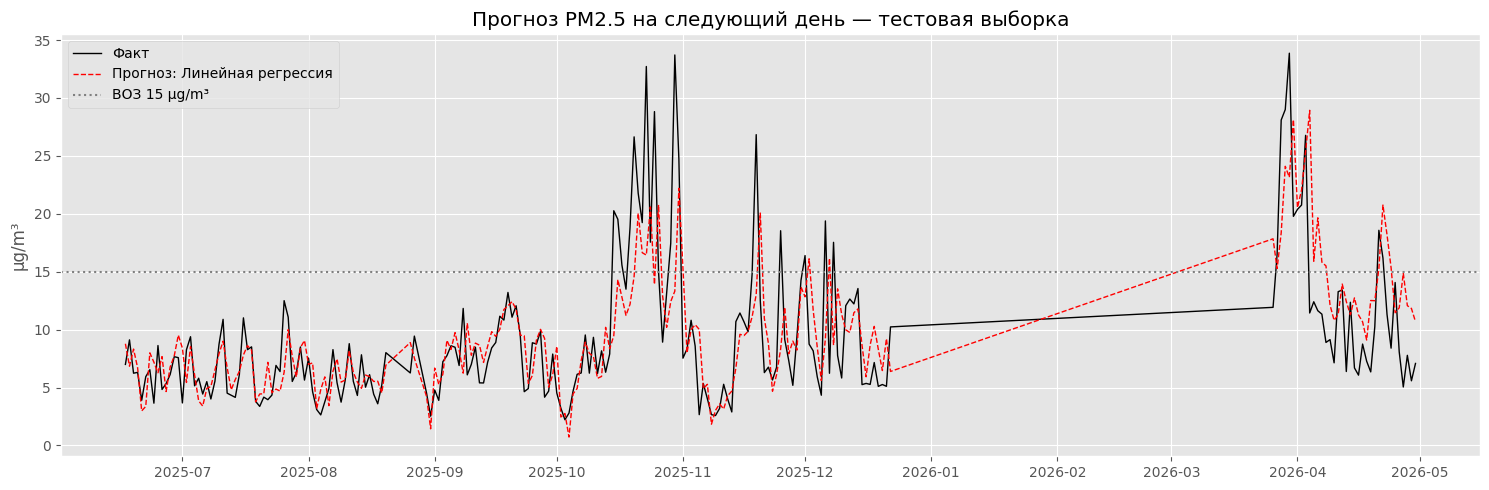

In [26]:
# Практическая метрика: насколько хорошо модель предупреждает о днях превышения ВОЗ (> 15 µg/m³)
best = results["MAE"].idxmin()
actual_bad = y_test > WHO_24H["pm2_5"]
pred_bad = predictions[best] > WHO_24H["pm2_5"]
recall = (actual_bad & pred_bad).sum() / actual_bad.sum()
precision = (actual_bad & pred_bad).sum() / max(pred_bad.sum(), 1)
print(f"Лучшая модель по MAE: {best}")
print(f"Дней превышения в тесте: {actual_bad.sum()}; модель поймала {recall:.0%} из них, "
      f"точность предупреждений {precision:.0%}")

plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label="Факт", color="black", lw=1)
plt.plot(y_test.index, predictions[best], label=f"Прогноз: {best}", color="red", ls="--", lw=1)
plt.axhline(WHO_24H["pm2_5"], color="grey", ls=":", label="ВОЗ 15 µg/m³")
plt.title("Прогноз PM2.5 на следующий день — тестовая выборка")
plt.ylabel("µg/m³"); plt.legend(); plt.tight_layout(); plt.show()

### Важность признаков

Permutation importance: насколько ухудшается MAE на тесте, если случайно перемешать один признак. Честнее встроенной важности случайного леса, потому что считается на тестовых данных.

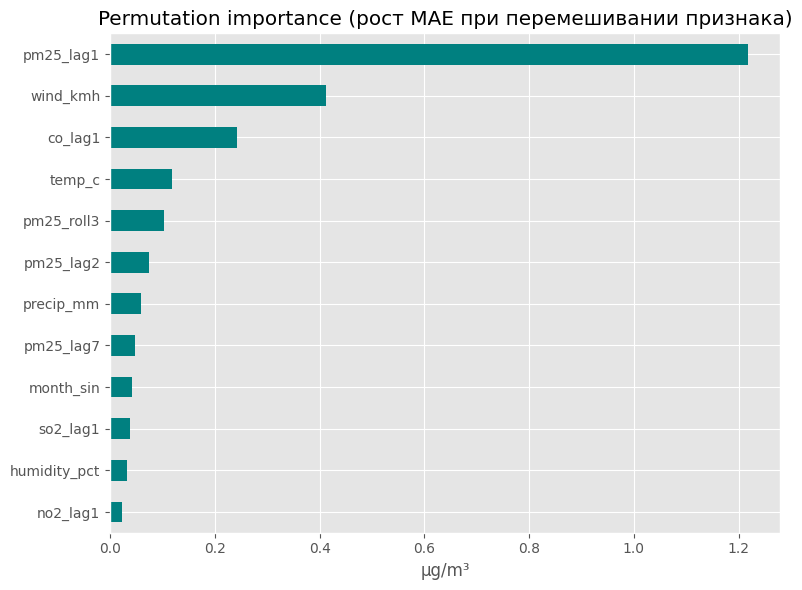

In [27]:
rf = models["Случайный лес"]
imp = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE,
                             scoring="neg_mean_absolute_error")
imp = pd.Series(imp.importances_mean, index=X_cols).sort_values()

plt.figure(figsize=(8, 6))
imp.tail(12).plot.barh(color="teal")
plt.title("Permutation importance (рост MAE при перемешивании признака)")
plt.xlabel("µg/m³")
plt.tight_layout(); plt.show()

## 12. Машинное обучение: поиск аномальных дней (Isolation Forest)

Ищем дни с **необычной комбинацией** загрязнителей (не просто «высокий PM2.5», а, например, резкий рост SO₂ при нормальной пыли) — это кандидаты на аварийные/залповые выбросы. Isolation Forest изолирует точки случайными разбиениями: аномалии изолируются быстрее.

In [28]:
anom_cols = ["pm2_5", "pm10", "no2", "so2", "co", "h2s"]
X_anom = city[anom_cols].dropna()
X_scaled = StandardScaler().fit_transform(np.log1p(X_anom))   # log сглаживает тяжёлые хвосты, scaler уравнивает масштабы

iso = IsolationForest(contamination=0.02, random_state=RANDOM_STATE)   # ожидаем ~2 % аномальных дней
X_anom = X_anom.assign(anomaly=iso.fit_predict(X_scaled) == -1,
                       score=-iso.score_samples(X_scaled))

print(f"Дней с полным набором загрязнителей: {len(X_anom)}, из них аномальных: {X_anom['anomaly'].sum()}")
top_anom = X_anom[X_anom["anomaly"]].sort_values("score", ascending=False)
top_anom.join(city[["temp_c", "wind_kmh"]]).head(10)

Дней с полным набором загрязнителей: 955, из них аномальных: 20


,pm2_5,pm10,no2,so2,co,h2s,anomaly,score,temp_c,wind_kmh
date,,,,,,,,,,
2025-03-29,56.85,111.21,21.84,16.65,2693.94,1.92,True,0.67,4.40,2.90
2025-11-10,3.19,5.14,0.83,3.92,420.47,7.30,True,0.64,-3.70,19.40
2025-11-09,2.58,4.82,1.30,5.03,184.15,13.25,True,0.64,1.20,18.40
2025-03-03,50.37,68.36,2.47,20.02,2115.92,2.09,True,0.64,-12.60,6.60
2023-02-01,43.95,52.59,79.37,23.10,2379.71,3.17,True,0.63,-17.20,6.00
2024-04-05,33.34,96.60,3.06,23.53,1380.01,0.47,True,0.63,9.00,7.90
2025-03-30,39.62,81.34,20.80,21.97,1726.71,2.93,True,0.63,5.30,5.20
2025-11-08,2.66,6.45,0.86,5.69,127.14,4.30,True,0.62,0.80,23.10
2023-02-17,37.20,46.55,91.57,20.86,1123.35,4.78,True,0.62,-15.80,12.50


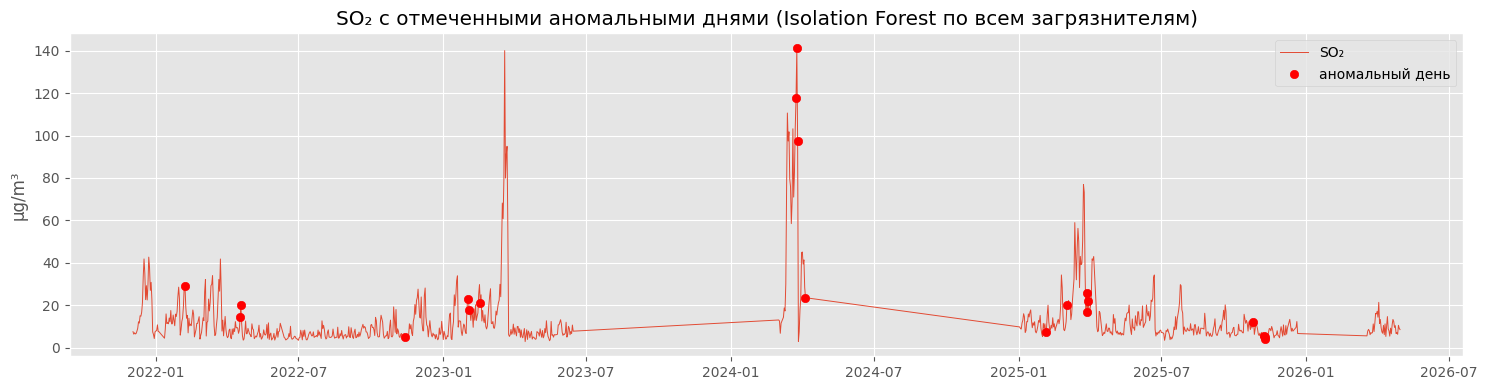

In [29]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(X_anom.index, X_anom["so2"], lw=0.7, label="SO₂")
ax.scatter(top_anom.index, top_anom["so2"], color="red", zorder=3, label="аномальный день")
ax.set_title("SO₂ с отмеченными аномальными днями (Isolation Forest по всем загрязнителям)")
ax.set_ylabel("µg/m³"); ax.legend()
plt.tight_layout(); plt.show()

## 13. Сводка ключевых чисел для отчёта и презентации

In [30]:
summary = {
    "Среднее PM2.5, µg/m³": city["pm2_5"].mean(),
    "PM2.5: × годового норматива ВОЗ": city["pm2_5"].mean() / WHO_ANNUAL["pm2_5"],
    "% дней PM2.5 > ВОЗ (15)": 100 * (city["pm2_5"].dropna() > 15).mean(),
    "% дней PM2.5 > ПДК РК (35)": 100 * (city["pm2_5"].dropna() > 35).mean(),
    "% дней NO₂ > ВОЗ (25)": 100 * (city["no2"].dropna() > 25).mean(),
    "PM2.5: рост в отопительный сезон, раз": season_tbl.loc["pm2_5", "Рост зимой, раз"],
    "Корреляция PM2.5 ~ температура (Спирмен)": city[["pm2_5", "temp_c"]].corr("spearman").iloc[0, 1],
    "Корреляция PM2.5 ~ ветер (Спирмен)": city[["pm2_5", "wind_kmh"]].corr("spearman").iloc[0, 1],
    f"Прогноз: MAE лучшей модели ({best})": results.loc[best, "MAE"],
    "Прогноз: MAE персистентности": results.iloc[0]["MAE"],
    "Избыточный риск смертности от PM2.5, %": 100 * excess_risk,
}
pd.Series(summary).to_frame("значение")

,значение
"Среднее PM2.5, µg/m³",11.77
PM2.5: × годового норматива ВОЗ,2.35
% дней PM2.5 > ВОЗ (15),23.27
% дней PM2.5 > ПДК РК (35),3.05
% дней NO₂ > ВОЗ (25),52.40
"PM2.5: рост в отопительный сезон, раз",1.32
Корреляция PM2.5 ~ температура (Спирмен),-0.26
Корреляция PM2.5 ~ ветер (Спирмен),-0.26
Прогноз: MAE лучшей модели (Линейная регрессия),2.94
Прогноз: MAE персистентности,3.33


## 14. Выводы и рекомендации

### Ответы на исследовательские вопросы (по Павлодару)

**1. Насколько загрязнён воздух?**
Среднее PM2.5 за период ≈ **11.8 µg/m³**, это **≈ 2.4× годового норматива ВОЗ** (5 µg/m³). Суточный норматив ВОЗ (15 µg/m³) превышен примерно в **23 % дней** с данными. Национальную ПДК РК (35 µg/m³) PM2.5 превышает редко (~3 % дней): по меркам РК воздух «в норме», по меркам ВОЗ — нет. Эта разница в нормативах сама по себе важный вывод.

**2. Какие загрязнители самые проблемные?**
* **NO₂** — главный: > ВОЗ в ~52 % дней и > ПДК РК в ~30 % дней, среднее ≈ 3.4× годового норматива ВОЗ. Сильнее всего — пост **PCP #4** (≈ 3.6× норматива в среднем).
* **PM2.5** — второй по значимости (23 % дней > ВОЗ), наибольший вклад в риск для здоровья.
* **SO₂** — в среднем по городу ниже норматива, но на посту **PCP #7** в среднем ≈ 1.3× норматива ВОЗ: локальный промышленный источник.
* CO и H₂S почти всегда в норме; эпизод H₂S в ноябре 2025 (до 13 µg/m³ при ПДК 8) выявлен детектором аномалий.
* O₃ — данных всего ~2 месяца, выводы делать нельзя.

**3. Источники (по косвенным признакам в данных):**
* **Промышленность (точечные источники):** у SO₂ и NO₂ огромный разброс между постами (max/median = 5.4 и 3.1) — значит, их создают конкретные предприятия рядом с отдельными постами, а не «весь город».
* **Отопление и сжигание угля:** в отопительный сезон SO₂ выше в ~1.9 раза, NO₂ — в ~1.7, PM2.5 — в ~1.3.
* **Транспорт + отопление:** зимой у NO₂ и CO чёткие утренний (~9 ч) и вечерний (~20 ч) пики — «часы пик» плюс вечерняя топка.
* **Метеорология / инверсии:** PM2.5 максимален ночью (~3 ч) — ночное накопление у земли при слабом перемешивании. Корреляция PM2.5 с ветром и температурой отрицательная (ρ ≈ −0.26): в морозные безветренные дни воздух грязнее.
* **Пыль весной:** самые грязные дни по PM2.5 (апрель–май 2022–2023, март 2025) сопровождаются очень высоким PM10 — похоже на пылевые эпизоды / степные пожары, а не на отопление.

**4. Сезонность:** пик сезонной компоненты PM2.5 — январь, минимум — июнь, размах ≈ 17 µg/m³ (по декомпозиции 2021–2023).

**5. Прогноз (ML):** линейная регрессия на лагах PM2.5 + погоде предсказывает PM2.5 на завтра с MAE ≈ 2.9 µg/m³, это лучше базовой «персистентности» (MAE ≈ 3.3) и лучше случайного леса (на ~900 обучающих днях сложная модель переобучается). Модель ловит ~55 % дней превышения ВОЗ — достаточно для прототипа системы оповещения, но не для продакшена. Главные признаки: вчерашний PM2.5, **ветер**, вчерашний CO, температура.

### Ограничения
* В данных только Павлодар — сравнение городов заменено сравнением постов.
* Большие разрывы (PM2.5 почти нет с июля 2023 по январь 2025), посты работают в разные периоды → среднее по городу «плавает» от состава постов.
* ~20 % часовых данных отброшено как «залипшие» датчики — правило прозрачное, но пороговое.
* Погода — реанализ Open-Meteo (ERA5), а не городская метеостанция; в прогнозе используется фактическая погода как «идеальный метеопрогноз».

### Рекомендации

**Краткосрочные (1–2 года):**
1. **Система раннего оповещения** на основе прогнозной модели: при прогнозе > 15 µg/m³ и штиле — предупреждение жителям (дети, пожилые, астматики), ограничение выбросов на ТЭЦ/предприятиях в режиме НМУ (неблагоприятных метеоусловий).
2. **Проверка предприятий у постов PCP #4 (NO₂) и PCP #7 (SO₂)**: именно там локальные превышения; сверить с отчётами производственного экологического контроля.
3. **Ремонт и калибровка датчиков** Казгидромета: у PCP #5 PM-датчик месяцами показывает нижний предел, PCP #6 не передаёт PM с 2023 г. Без данных нет управления.
4. **Контроль частного сектора зимой**: пики PM2.5 ночью — перевод частных домов с угля на газ/электроотопление, контроль качества угля.

**Долгосрочные (5–10 лет):**
1. Модернизация угольных ТЭЦ (электрофильтры, сероочистка) и постепенный переход к газу/ВИЭ.
2. Перевод городских нормативов РК ближе к ВОЗ 2021 / стандартам ЕС (ЕС с 2030 г. — 10 µg/m³ среднегодового PM2.5).
3. Санитарно-защитные зелёные зоны между промзоной и жилыми районами; озеленение против весенней пыли.
4. Расширение сети постов и открытых данных, чтобы модель можно было обучать на нескольких городах (Алматы, Астана, Караганда, Темиртау).